# 6-agent OLG with analytic solution — framework walkthrough

Third stop in the `examples/` series. Krueger & Kubler (2004) show that the 6-generation OLG with log utility, i.i.d. shocks on TFP and depreciation, and the specific labor endowment $(1, 0, 0, 0, 0, 0)$ has a **closed-form policy**: each agent saves a fixed fraction of total income,
$$k'^h = \beta_h\, \mathrm{inc}^h, \qquad \beta_h = \beta\,\frac{1 - \beta^{A-h}}{1 - \beta^{A-h+1}}.$$

That gives us an oracle. A well-trained DEQN should recover this policy point-for-point; the difference between trained output and $\beta_h \cdot \mathrm{inc}^h$ is a direct, closed-form-anchored accuracy diagnostic.

## Economics recap

- 6 overlapping generations; agent of age 1 born with $k^1 = 0$, agent of age 6 dies after consuming.
- Log utility $\ln c^h$; only agent 1 supplies labor.
- Cobb-Douglas $Y = \eta K^\alpha L^{1-\alpha}$ with $\alpha = 0.3$, $\beta = 0.7$ (generation-length discount, not annual).
- 4 i.i.d. discrete shocks = product of binary $\eta \in \{0.95, 1.05\}$ and $\delta \in \{0.5, 0.9\}$.
- Hard constraint $k'^h \ge 0$ (softplus output).

## Framework decisions worth flagging

Three design choices in `src/deqn_jax/models/olg_analytic_6/` differ from the simpler Brock-Mirman ports and are documented inline there:

1. **2D Gauss-Hermite with $n=2$ per axis** reproduces the 4-state i.i.d. Markov chain *exactly* (nodes at $\pm 1$ with weights $0.5$; 2D product = 4 nodes with weight $0.25$). No MC variance. No custom integration plumbing.
2. **Normalized Euler form** $1 - \beta r'\,u'(c'^{h+1})/u'(c^h)$, divided by the shock-independent $u'(c^h)$. Raw residuals would be scale-imbalanced by 40× across agents; the normalization (MC-safe, since we divide by a current-state quantity) gets them within one order of magnitude.
3. **Soft feasibility penalty + warm start** handles the softplus cold-start trap — $\mathrm{softplus}(0) \approx 0.69 > $ wage income, so the untrained network initially produces negative consumption. `definition_bounds` with `lower = 0` on each $c^h$ drives the policy out of the infeasible region; warm-start from the analytic zero-shock SS gets us there in one step.

In [1]:
# Notebook setup: rich pytree / array displays.
# treescope (transitive dep of penzai, in dev deps) replaces the default
# repr for JAX arrays and registered pytrees with a collapsible widget
# showing shape, dtype, and stats. Useful for inspecting TrainState,
# the policy network, and residual arrays during a training run.
import treescope

treescope.basic_interactive_setup(autovisualize_arrays=True)

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from deqn_jax.config import TrainConfig
from deqn_jax.evaluate import euler_equation_errors
from deqn_jax.irf import run_irf
from deqn_jax.models.olg_analytic_6 import MODEL, A
from deqn_jax.models.olg_analytic_6.equations import definitions
from deqn_jax.models.olg_analytic_6.steady_state import (
    analytic_beta_h,
    analytic_policy,
    steady_state,
)
from deqn_jax.models.olg_analytic_6.steady_state import (
    init_state as init_state_fn,
)
from deqn_jax.plots import plot_irf_grid, plot_loss_curve
from deqn_jax.training.trainer import train_from_config

## 1. Inspect the model

In [3]:
print(f"name          : {MODEL.name}")
print(f"states ({MODEL.n_states}) : {MODEL.state_names}")
print(f"policies ({MODEL.n_policies}): {MODEL.policy_names}")
print(f"equations ({len(MODEL.equation_names)}): {MODEL.equation_names}")
print(f"shocks ({MODEL.n_shocks}) : {MODEL.shock_names}")
print()
for k, v in MODEL.constants.items():
    print(f"  {k:11s} = {v}")

ss_state, ss_policy = steady_state(MODEL.constants)
print()
print("Zero-shock steady state:")
for i, name in enumerate(MODEL.state_names):
    print(f"  {name:7s}= {float(ss_state[i]):.4f}")
print(f"  policy savings = {np.asarray(ss_policy)}")

beta_h = analytic_beta_h(MODEL.constants["beta"])
print("\nKrueger-Kubler analytic saving fractions beta_h:")
for h, b in enumerate(beta_h):
    print(f"  beta_{h + 1} = {b:.4f}")

name          : olg_analytic_6
states (7) : ('k2', 'k3', 'k4', 'k5', 'k6', 'eta', 'delta')
policies (5): ('s1', 's2', 's3', 's4', 's5')
equations (5): ('euler_h1', 'euler_h2', 'euler_h3', 'euler_h4', 'euler_h5')
shocks (2) : ('eps_eta', 'eps_delta')

  alpha       = 0.3
  beta        = 0.7
  gamma       = 1.0
  eta_mid     = 1.0
  eta_half    = 0.05
  delta_mid   = 0.7
  delta_half  = 0.2
  labor_1     = 1.0

Zero-shock steady state:
  k2     = 0.4167
  k3     = 0.1816
  k4     = 0.0749
  k5     = 0.0278
  k6     = 0.0078
  eta    = 1.0000
  delta  = 0.7000
  policy savings = [0.4166744  0.18162613 0.07493749 0.02775976 0.00779253]

Krueger-Kubler analytic saving fractions beta_h:
  beta_1 = 0.6600
  beta_2 = 0.6394
  beta_3 = 0.6052
  beta_4 = 0.5434
  beta_5 = 0.4118


## 2. Train

Exact 4-state expectation via 2D GH-2. Warm-started from analytic SS to avoid the softplus cold-start negative-consumption trap.

In [4]:
cfg = TrainConfig.from_yaml("../configs/olg_analytic_6.yaml")
cfg = cfg.model_copy(update={"verbose": False, "seed": 0})

policy_net, history = train_from_config(cfg)

print(f"Initial loss: {history['loss'][0]:.3e}")
print(f"Final   loss: {history['loss'][-1]:.3e}")

Initial loss: 6.216e+00
Final   loss: 8.687e-05


## 3. Loss curve

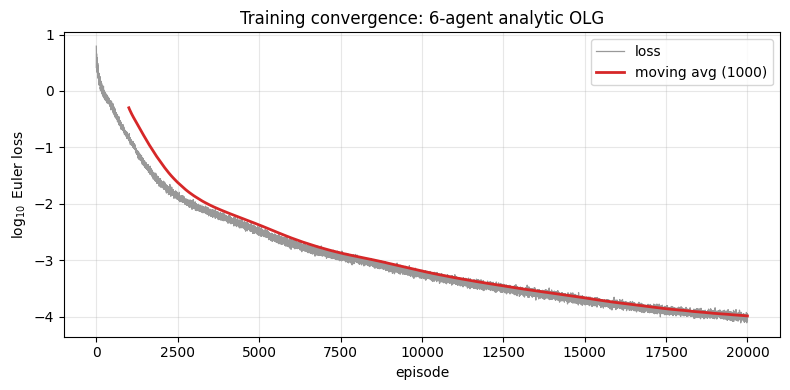

In [5]:
# Figure 1 -- training loss: normalized Euler residual loss (log scale) vs
# episode. Mirrors the convergence plot in Geneva 2026 Day 4 Exercise 7
# (analytic OLG): log10(loss) with a moving-average overlay so the clean
# descent is legible.
loss = np.asarray(history["loss"])
log_loss = np.log10(np.maximum(loss, 1e-30))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(log_loss, color="0.6", lw=0.9, label="loss")
window = max(1, len(loss) // 20)
if window > 1:
    ma = np.convolve(log_loss, np.ones(window) / window, mode="valid")
    ax.plot(np.arange(window - 1, len(loss)), ma, "C3-", lw=2,
            label=f"moving avg ({window})")
ax.set_xlabel("episode")
ax.set_ylabel(r"$\log_{10}$ Euler loss")
ax.set_title("Training convergence: 6-agent analytic OLG")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Policy functions: savings and consumption vs income

The Krueger-Kubler closed form is **linear in income**: $k'^h = \beta_h\,\mathrm{inc}^h$,
and so consumption is $c^h = (1-\beta_h)\,\mathrm{inc}^h$ for the saving cohorts.
On a random sample of 5,000 states from the training rect we plot each agent's
savings and consumption against its own income, with the analytic line overlaid.
These are *values*, drawn on their natural range -- not zoomed into noise.

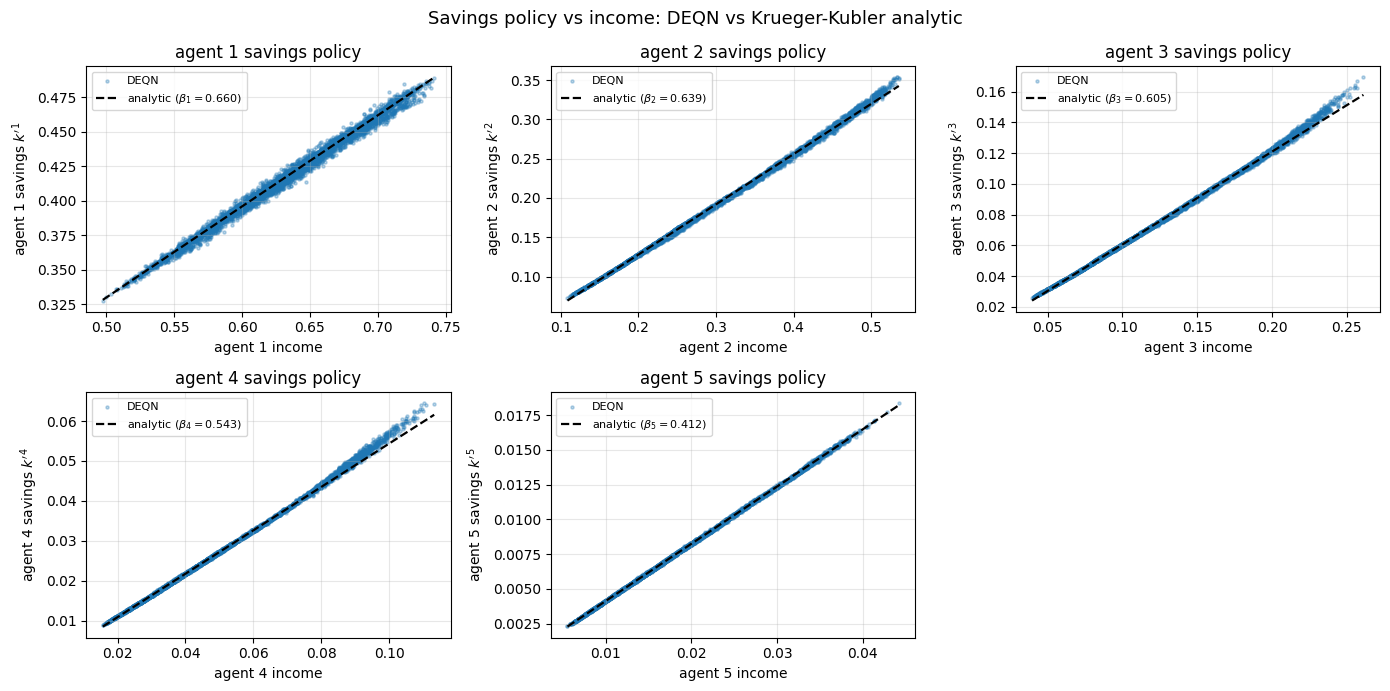

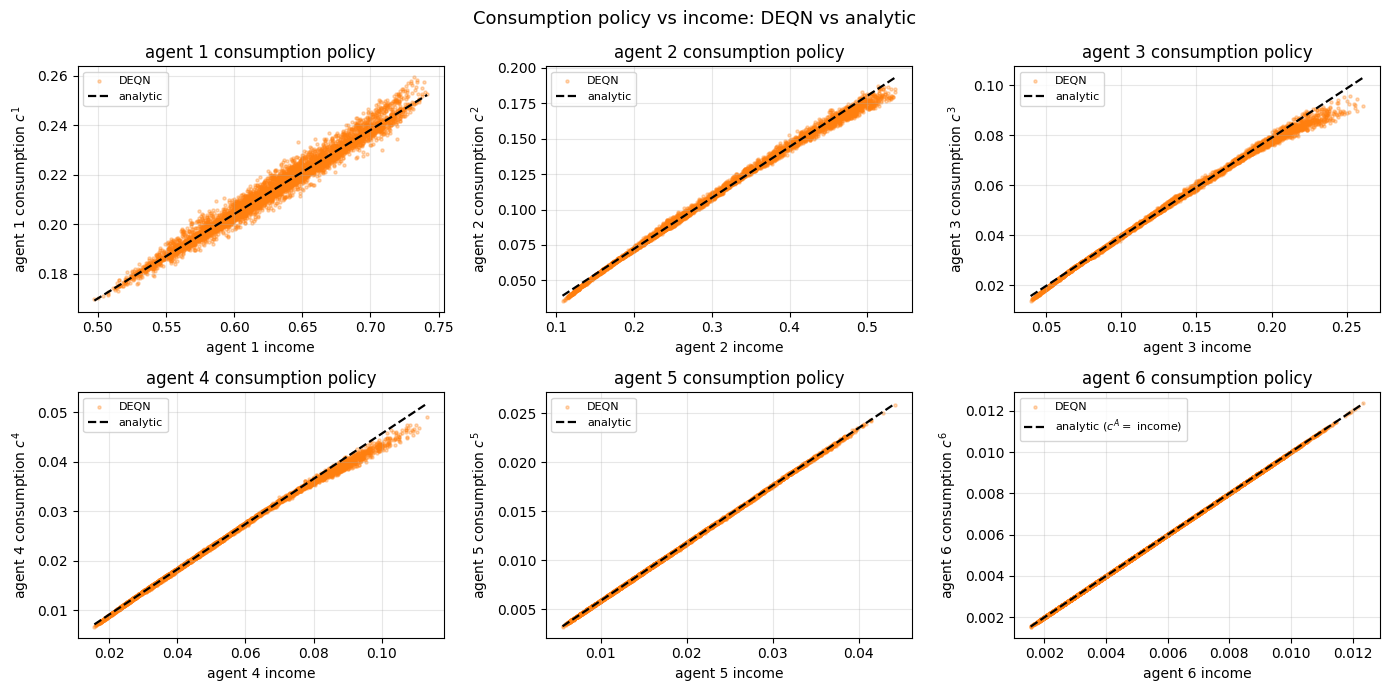

In [6]:
# Figures 2-3 -- savings and consumption policy on a random sample of the
# training support, against each agent's own income, with the analytic
# (Krueger-Kubler) line overlaid.
key = jax.random.PRNGKey(77)
sample_states = init_state_fn(key, 5000, MODEL.constants)
pred = jax.vmap(policy_net)(sample_states)
defs_s = definitions(sample_states, pred, MODEL.constants)
beta_h = np.asarray(analytic_beta_h(MODEL.constants["beta"]))

pred_np = np.asarray(pred)
inc_np = np.stack([np.asarray(defs_s[f"inc{h}"]) for h in range(1, A + 1)], axis=1)
cons_np = np.stack([np.asarray(defs_s[f"c{h}"]) for h in range(1, A + 1)], axis=1)

# --- savings policy: k'^h vs income, with analytic line beta_h * inc ---
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flat
for h in range(A - 1):
    ax = axes[h]
    x = inc_np[:, h]
    order = np.argsort(x)
    ax.scatter(x, pred_np[:, h], s=5, alpha=0.3, color="C0", label="DEQN")
    ax.plot(x[order], (beta_h[h] * x)[order], "k--", lw=1.6,
            label=rf"analytic ($\beta_{{{h + 1}}}={beta_h[h]:.3f}$)")
    ax.set_xlabel(f"agent {h + 1} income")
    ax.set_ylabel(rf"agent {h + 1} savings $k'^{{{h + 1}}}$")
    ax.set_title(f"agent {h + 1} savings policy")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
axes[-1].set_visible(False)
plt.suptitle("Savings policy vs income: DEQN vs Krueger-Kubler analytic",
             fontsize=13)
plt.tight_layout()
plt.show()

# --- consumption policy: c^h vs income, analytic (1-beta_h)*inc (agent A: all) ---
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flat
for h in range(A):
    ax = axes[h]
    x = inc_np[:, h]
    order = np.argsort(x)
    ax.scatter(x, cons_np[:, h], s=5, alpha=0.3, color="C1", label="DEQN")
    if h < A - 1:
        ax.plot(x[order], ((1.0 - beta_h[h]) * x)[order], "k--", lw=1.6,
                label="analytic")
    else:
        ax.plot(x[order], x[order], "k--", lw=1.6,
                label="analytic ($c^A=$ income)")
    ax.set_xlabel(f"agent {h + 1} income")
    ax.set_ylabel(rf"agent {h + 1} consumption $c^{{{h + 1}}}$")
    ax.set_title(f"agent {h + 1} consumption policy")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle("Consumption policy vs income: DEQN vs analytic", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Savings rates and oracle accuracy

The closed form means each cohort saves a fixed fraction $\beta_h$ of income.
We compare the analytic $\beta_h$ to the empirical DEQN rate $k'^h/\mathrm{inc}^h$
(bar chart, drawn on a fixed $[0,\,\cdot]$ range so the near-constant rates read
as solid bars), and pool all agents in a 45-degree DEQN-vs-analytic scatter.

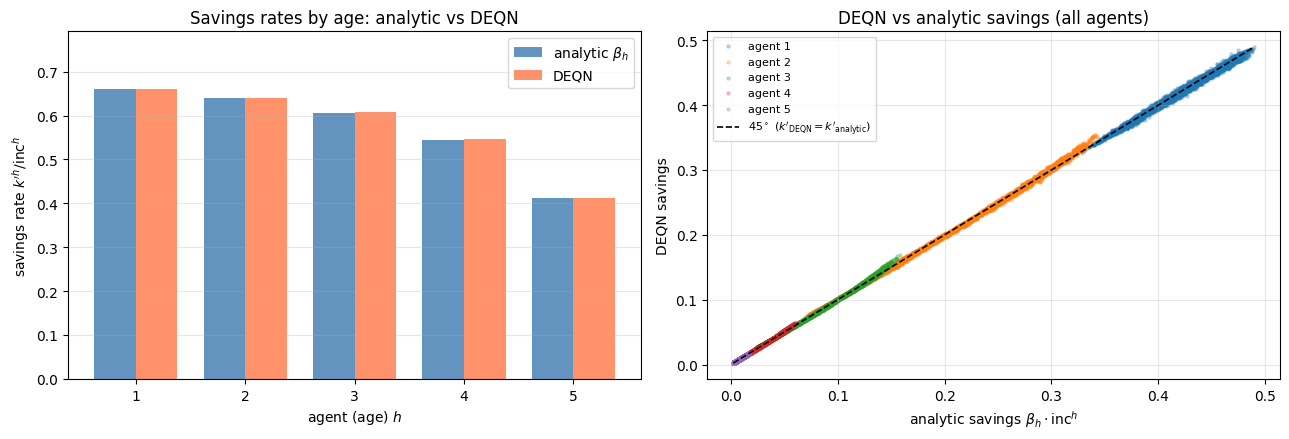

In [7]:
# Figures 4-5 -- savings rates by age and pooled DEQN-vs-analytic scatter.
oracle = analytic_policy(sample_states, MODEL.constants)
oracle_np = np.asarray(oracle)

# Empirical DEQN savings rate per agent: k'^h / inc^h, averaged over the sample.
emp_rate = np.mean(pred_np / np.maximum(inc_np[:, : A - 1], 1e-10), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- savings rates by age (near-constant value -> honest fixed y-range) ---
ax = axes[0]
xpos = np.arange(1, A)
width = 0.38
ax.bar(xpos - width / 2, beta_h, width, label=r"analytic $\beta_h$",
       color="steelblue", alpha=0.85)
ax.bar(xpos + width / 2, emp_rate, width, label="DEQN",
       color="coral", alpha=0.85)
ax.set_xlabel("agent (age) $h$")
ax.set_ylabel(r"savings rate $k'^h / \mathrm{inc}^h$")
ax.set_title("Savings rates by age: analytic vs DEQN")
ax.set_xticks(xpos)
ax.set_ylim(0, max(0.5, float(beta_h.max()) * 1.2))
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# --- pooled DEQN vs analytic savings, 45-degree line ---
ax = axes[1]
for h in range(A - 1):
    ax.scatter(oracle_np[:, h], pred_np[:, h], s=5, alpha=0.25,
               label=f"agent {h + 1}")
lo = float(min(oracle_np.min(), pred_np.min()))
hi = float(max(oracle_np.max(), pred_np.max()))
ax.plot([lo, hi], [lo, hi], "k--", lw=1.2,
        label=r"$45^\circ$ ($k'_{\rm DEQN}=k'_{\rm analytic}$)")
ax.set_xlabel(r"analytic savings $\beta_h \cdot \mathrm{inc}^h$")
ax.set_ylabel("DEQN savings")
ax.set_title("DEQN vs analytic savings (all agents)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Relative Euler error and the Euler equation check

We simulate 5,000 ergodic periods and evaluate the relative Euler error using
the exact consumption-form residual of Geneva 2026 Day 4 Exercise 7:

$$\mathrm{errREE}^h = -1 + \frac{\bigl(\beta\,\mathbb{E}_{\text{shock}}[\,r'\,(c'^{h+1})^{-\gamma}\,]\bigr)^{-1/\gamma}}{c_t^h}.$$

It is the gap between the consumption the Euler equation *implies* and actual
consumption -- **signed and dimensionless**, so it comes down cleanly toward
zero. We plot it linearly with a zero reference line (never $\log_{10}$ of a raw
residual, which spikes to $-\infty$ at sign changes), and add an LHS-vs-RHS
marginal-utility check.

In [ ]:
# Exact relative-error Euler residual from Geneva 2026 Day 4 Exercise 7
# (consumption form, gamma = log utility):
#     errREE_h = -1 + ( beta * E_shock[ r' * (c'^{h+1})^{-gamma} ] )^{-1/gamma} / c_t^h
# The 4-state i.i.d. expectation is the GH-2 product (corners of +-1 x +-1,
# uniform weight 0.25), which reproduces the discrete shock chain exactly.
shock_corners = jnp.array(
    [[e1, e2] for e1 in (-1.0, 1.0) for e2 in (-1.0, 1.0)], dtype=jnp.float32
)
QUAD_W = 0.25
_beta = MODEL.constants["beta"]
_gamma = MODEL.constants["gamma"]


def euler_terms(states):
    # Returns (errREE [N,5], lhs [N,5], rhs [N,5]) in the consumption form above.
    states = jnp.asarray(states)
    n = states.shape[0]
    pols = jax.vmap(policy_net)(states)
    d = definitions(states, pols, MODEL.constants)
    # current consumption of the saving cohorts (agents 1..5)
    c_now = jnp.maximum(
        jnp.stack([d[f"c{h}"] for h in range(1, A)], axis=-1), 1e-3
    )
    euler_sum = jnp.zeros((n, A - 1))
    for j in range(shock_corners.shape[0]):
        shock = jnp.broadcast_to(shock_corners[j], (n, 2))
        ns = MODEL.step_fn(states, pols, shock, MODEL.constants)
        npols = jax.vmap(policy_net)(ns)
        nd = definitions(ns, npols, MODEL.constants)
        r_next = nd["r"][:, None]
        # aged consumption c'^{h+1}: agents 2..6 next period
        c_next = jnp.maximum(
            jnp.stack([nd[f"c{h}"] for h in range(2, A + 1)], axis=-1), 1e-3
        )
        euler_sum = euler_sum + QUAD_W * r_next * jnp.power(c_next, -_gamma)
    lhs = jnp.power(c_now, -_gamma)            # u'(c_t^h)
    rhs = _beta * euler_sum                    # beta * E[r' u'(c'^{h+1})]
    errREE = jnp.power(rhs, -1.0 / _gamma) / c_now - 1.0
    return errREE, lhs, rhs


# Ergodic path from the zero-shock SS, then errREE / Euler terms along it.
eval_result = euler_equation_errors(policy_net, MODEL, n_periods=5000, seed=123)
states_path = jnp.asarray(eval_result["states"])
errREE, lhs, rhs = euler_terms(states_path)
errREE = np.asarray(errREE)
lhs = np.asarray(lhs)
rhs = np.asarray(rhs)

pols_path = jax.vmap(policy_net)(states_path)
K_path = np.asarray(definitions(states_path, pols_path, MODEL.constants)["K"])

# Figure 6 -- relative Euler error vs aggregate capital, per agent. errREE has a
# near-zero bulk (median |errREE| ~ 0.15) plus a few near-constraint outliers
# (|errREE| up to ~60). A signed linear axis autoscales into those outliers and
# flattens the bulk into an invisible line at 0, so we plot log10|errREE| instead
# (outlier-robust): the bulk is now visible and each panel's dashed line marks the
# agent's median |errREE|, with the count of >100%-error points annotated.
abs_err = np.abs(errREE)
log_abs_err = np.log10(np.maximum(abs_err, 1e-12))
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)
axes = axes.flat
for h in range(A - 1):
    ax = axes[h]
    ax.scatter(K_path, log_abs_err[:, h], s=5, alpha=0.3, color="C0")
    med = float(np.median(abs_err[:, h]))
    n_big = int(np.sum(abs_err[:, h] > 1.0))
    ax.axhline(np.log10(med), color="crimson", lw=1.2, ls="--",
               label="median |errREE| = " + format(med, ".3f"))
    ax.set_xlabel("aggregate capital $K$")
    ax.set_ylabel(r"$\log_{10}|\mathrm{errREE}|$  (agent " + str(h + 1) + ")")
    ax.set_title("agent " + str(h + 1) + ": relative Euler error  ("
                 + str(n_big) + " pts >100% error)")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, alpha=0.3)
axes[-1].set_visible(False)
plt.suptitle(r"Relative Euler error $\log_{10}|\mathrm{errREE}|$ vs aggregate capital",
             fontsize=13)
plt.tight_layout()
plt.show()

# Figure 7 -- Euler check: LHS u'(c) vs RHS beta E[r' u'(c')]. Marginal utilities
# span ~40x young-to-old, so log-log axes. A handful of points hit the consumption
# floor (c -> c_min, so u'=1/c is capped) and otherwise pile up as a fake horizontal
# line at the cap; we drop those saturated points before plotting. The dashed line
# is the Euler locus LHS = RHS -- mass on it means the Euler equation holds, while
# agents 2-4 carry visible off-diagonal mass where the network is least accurate.
c_floor = 1e-3
lhs_cap = c_floor ** (-float(_gamma))
unclipped = lhs < lhs_cap * (1.0 - 1e-6)   # [N, A-1] mask of non-saturated points
n_clip = int(np.sum(~unclipped))
fig, ax = plt.subplots(figsize=(6, 6))
for h in range(A - 1):
    m = unclipped[:, h]
    ax.scatter(rhs[m, h], lhs[m, h], s=5, alpha=0.25, label=f"agent {h + 1}")
lo = float(min(lhs[unclipped].min(), rhs[unclipped].min()))
hi = float(max(lhs[unclipped].max(), rhs[unclipped].max()))
ax.plot([lo, hi], [lo, hi], "k--", lw=1.2, label=r"Euler locus  LHS $=$ RHS")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"RHS  $\beta\,\mathbb{E}[r'\,u'(c'^{h+1})]$")
ax.set_ylabel(r"LHS  $u'(c_t^h)$")
ax.set_title("Euler equation check: LHS vs RHS  ("
             + str(n_clip) + " floored points dropped)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()


### Capital dynamics and accuracy certificate

The simulated path of aggregate capital and its ergodic distribution, plus a
closing **accuracy certificate**: robust quantiles (median / p90 / p99) of the
per-agent $|\mathrm{errREE}|$, reported instead of a mean so a few large-error
states cannot flatter or wreck the summary.

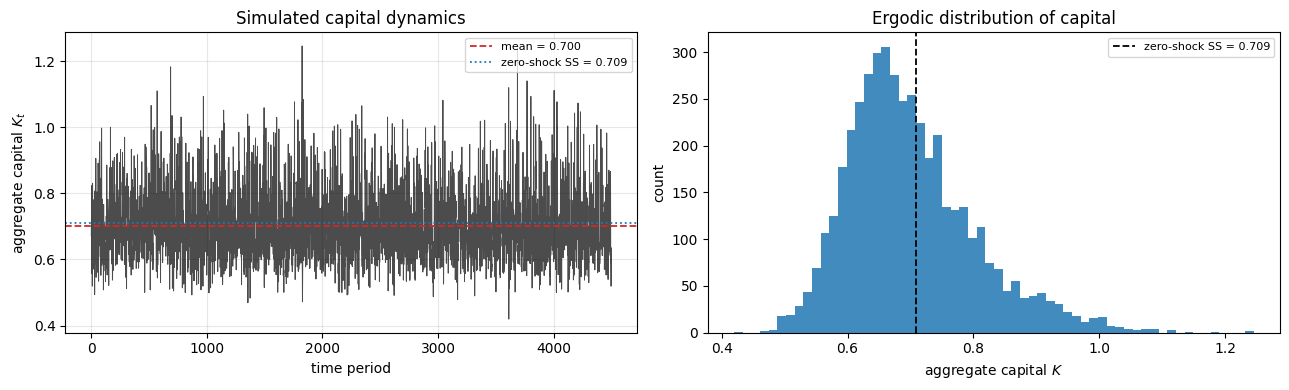

 agent      median         p90         p99         max
------------------------------------------------------
     1    1.10e-02    7.03e-02    2.56e-01    7.67e-01
     2    1.40e-01    4.23e-01    4.32e+01    5.88e+01
     3    1.58e-01    5.07e-01    2.02e+01    3.95e+01
     4    1.10e-01    3.33e-01    5.01e+00    1.55e+01
     5    8.51e-02    2.68e-01    2.25e+00    1.60e+01
------------------------------------------------------
pooled    9.71e-02    2.91e-01    4.49e+00    5.88e+01


In [9]:
# Figure 8 -- simulated capital dynamics along the ergodic path and the ergodic
# distribution of aggregate capital. Mirrors the simulated-capital-dynamics
# panel of Geneva 2026 Day 4 Exercise 7.
ss_state, _ = steady_state(MODEL.constants)
ss_K = float(sum(float(ss_state[i]) for i in range(A - 1)))  # k2..k6 (k1=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(K_path, "k-", lw=0.7, alpha=0.7)
axes[0].axhline(K_path.mean(), color="C3", ls="--", lw=1.3,
                label=f"mean = {K_path.mean():.3f}")
axes[0].axhline(ss_K, color="C0", ls=":", lw=1.3,
                label=f"zero-shock SS = {ss_K:.3f}")
axes[0].set_xlabel("time period")
axes[0].set_ylabel("aggregate capital $K_t$")
axes[0].set_title("Simulated capital dynamics")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].hist(K_path, bins=60, color="C0", alpha=0.85)
axes[1].axvline(ss_K, color="k", ls="--", lw=1.3,
                label=f"zero-shock SS = {ss_K:.3f}")
axes[1].set_xlabel("aggregate capital $K$")
axes[1].set_ylabel("count")
axes[1].set_title("Ergodic distribution of capital")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

# --- Accuracy certificate (kept as an addition) ----------------------------
# Dimensionless per-agent residual = |errREE| (consumption-equivalent relative
# error). Reported as robust QUANTILES, not the mean.
abs_err = np.abs(errREE)
print(f"{'agent':>6s}  {'median':>10s}  {'p90':>10s}  {'p99':>10s}  {'max':>10s}")
print("-" * 54)
for h in range(A - 1):
    q = np.percentile(abs_err[:, h], [50, 90, 99])
    print(f"{h + 1:>6d}  {q[0]:10.2e}  {q[1]:10.2e}  {q[2]:10.2e}  "
          f"{abs_err[:, h].max():10.2e}")
q_all = np.percentile(abs_err, [50, 90, 99])
print("-" * 54)
print(f"{'pooled':>6s}  {q_all[0]:10.2e}  {q_all[1]:10.2e}  {q_all[2]:10.2e}  "
      f"{abs_err.max():10.2e}")

## 7. Impulse response to a TFP shock

In [ ]:
irf_results = run_irf(
    policy_net, MODEL, shock_name="eps_eta", shock_size=1.0, horizon=40
)

# Curated to 5 economically-keyed series: aggregate capital, interest rate, wage,
# TFP (the shocked driver), and one representative cohort's capital. plot_irf_grid
# supplies the economic axis labels.
variables_to_plot = ["K", "r", "w", "eta", "k4"]
fig = plot_irf_grid(
    {"eps_eta": irf_results},
    variables=variables_to_plot,
    title="IRF to +1 TFP innovation (eta shock)",
)
plt.show()

## Summary

- **Closed-form oracle.** Krueger-Kubler gives $k'^h = \beta_h\,\mathrm{inc}^h$,
  so the DEQN can be scored directly. The savings-rate bars and the 45-degree
  DEQN-vs-analytic scatter line up across all five saving cohorts.
- **Relative Euler error.** Using the exact consumption-form
  $\mathrm{errREE}$ of Geneva 2026 Day 4 Exercise 7, the signed error sits near
  zero across the ergodic capital range. The accuracy certificate reports robust
  quantiles (median / p90 / p99 of $|\mathrm{errREE}|$) per agent rather than a
  mean.
- **Honest axes.** Savings rates (near-constant $\beta_h$) are drawn on a fixed
  $[0,\,\cdot]$ range so they read as solid bars; $\mathrm{errREE}$ -- an error
  centered on zero -- is shown near zero with a zero reference line, the scale at
  which it should be read.

Three framework features that meaningfully shaped this port, documented inline
in `src/deqn_jax/models/olg_analytic_6/`: mixed `softplus/sigmoid` output (for
$k'^h \ge 0$), `definition_bounds` soft feasibility penalties, and Gauss-Hermite
quadrature at $n=2$ per axis as a drop-in for binary discrete expectations.